# Walmart Retail Sales Forecasting — End-to-End Time-Series Project

## Models used
1. **SARIMAX**
2. **STL + Exponential Smoothing**
3. **Prophet**
4. **Unobserved Components Model (UCM)**
5. **Theta**
6. **Equal-weight Ensemble**

This notebook is written for a beginner. Each major section explains **what we are doing, why we are doing it, and what the output means**.

---

## Business problem

Walmart wants to estimate future sales so that inventory, staffing, and promotions can be planned more effectively.

The original dataset contains weekly observations for **45 Walmart stores**. For this project, we create a **Walmart-wide weekly sales series** by summing sales across all stores for every date.

Why aggregate?

- It gives us one clean business-level time series.
- It is easier to understand and explain in interviews.
- We can compare multiple forecasting algorithms fairly on the same target.
- It avoids training 45 separate forecasting models in a beginner project.

---

## Dataset

Kaggle dataset:

**Walmart Dataset — Walmart Store Sales Prediction - Regression Problem**  
Dataset owner/slug: `yasserh/walmart-dataset`

Expected columns:

- `Store`
- `Date`
- `Weekly_Sales`
- `Holiday_Flag`
- `Temperature`
- `Fuel_Price`
- `CPI`
- `Unemployment`

### Local setup

The dataset included with this project is [Dataset/Walmart.csv](Dataset/Walmart.csv).
The notebook reads this local file directly.

Select **Python (Walmart Forecasting)** or the project's `.venv/Scripts/python.exe`
as the notebook kernel, then choose **Run All**. See `README.md` for setup and
command-line execution instructions.


In [1]:
# 0. CHECK THE NOTEBOOK ENVIRONMENT
import sys
import importlib.util

required_modules = [
    "pandas", "numpy", "matplotlib", "statsmodels", "sklearn", "prophet"
]
missing = [name for name in required_modules
           if importlib.util.find_spec(name) is None]
if missing:
    raise ImportError(
        f"Missing packages: {', '.join(missing)}. "
        "Select the project's .venv kernel, or install requirements.txt "
        "using this kernel's Python interpreter."
    )
print("Python interpreter:", sys.executable)
print("Package check complete.")


Python interpreter: C:\Users\dev\OneDrive\Desktop\Forecasting\.venv\Scripts\python.exe
Package check complete.


In [2]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

%matplotlib inline

from IPython.display import display
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.forecasting.stl import STLForecast
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.structural import UnobservedComponents
from statsmodels.tsa.forecasting.theta import ThetaModel
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller

from prophet import Prophet

print("All libraries imported successfully.")

C:\Users\dev\OneDrive\Desktop\Forecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


All libraries imported successfully.


# 2. Configuration

The Walmart dataset is **weekly**, not daily.

Therefore:

- 1 month ≈ 4.33 weeks
- 3 months ≈ **13 weeks**

We will keep the **last 13 weekly observations completely unseen during training**.

This is called a **holdout / backtest period**.

### Why not use random train-test split?

Time-series observations have chronological order.

We must train on the **past** and test on the **future**.

Randomly shuffling the data would cause **future information leakage**.

In [3]:
# 2. CONFIGURATION
# Locate the project when launched from its root or a subdirectory.
PROJECT_DIR = next(
    (folder for folder in [Path.cwd(), *Path.cwd().parents]
     if (folder / "Dataset" / "Walmart.csv").is_file()),
    None,
)
if PROJECT_DIR is None:
    raise FileNotFoundError(
        "Dataset/Walmart.csv was not found. Open this notebook from the "
        "Forecasting project folder and keep the Dataset folder beside it."
    )
DATA_FILE = PROJECT_DIR / "Dataset" / "Walmart.csv"
TEST_WEEKS = 13
SEASONAL_PERIOD = 52
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print("Holdout period:", TEST_WEEKS, "weeks")
print("Annual seasonal period:", SEASONAL_PERIOD, "weeks")


Holdout period: 13 weeks
Annual seasonal period: 52 weeks


In [4]:
# 3. USE THE PROVIDED LOCAL DATASET
print("Using local dataset:", DATA_FILE.resolve())


Using local dataset: C:\Users\dev\OneDrive\Desktop\Forecasting\Dataset\Walmart.csv


In [5]:
# ============================================================
# 4. LOAD AND INSPECT THE RAW DATA
# ============================================================

df = pd.read_csv(DATA_FILE)

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(list(df.columns))

display(df.head())

Dataset shape: (6435, 8)

Column names:
['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [6]:
# ============================================================
# 5. VALIDATE DATASET STRUCTURE
# ============================================================

expected_columns = {
    "Store",
    "Date",
    "Weekly_Sales",
    "Holiday_Flag",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment"
}

missing_columns = expected_columns - set(df.columns)

if missing_columns:
    raise ValueError(
        "The local file does not match the expected Walmart dataset. "
        f"Missing columns: {missing_columns}"
    )

print("Dataset schema validated successfully.")

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nDuplicate rows:", df.duplicated().sum())

Dataset schema validated successfully.

Missing values:


,missing_values
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0



Duplicate rows: 0


# 6. Data preparation

The `Date` column is stored as text in **day-month-year** format.

We convert it to a real datetime object so Pandas and forecasting models understand chronological order.

We also make sure `Weekly_Sales` is numeric.

In [7]:
# ============================================================
# 6. CLEAN DATA TYPES
# ============================================================

df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y", errors="coerce")
df["Weekly_Sales"] = pd.to_numeric(df["Weekly_Sales"], errors="coerce")
df["Holiday_Flag"] = pd.to_numeric(df["Holiday_Flag"], errors="coerce")

if df["Date"].isna().any():
    raise ValueError("Some Date values could not be parsed.")

if df["Weekly_Sales"].isna().any():
    raise ValueError("Weekly_Sales contains missing/non-numeric values.")

print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("Number of stores:", df["Store"].nunique())
print("Number of unique weeks:", df["Date"].nunique())

Date range: 2010-02-05 to 2012-10-26
Number of stores: 45
Number of unique weeks: 143


# 7. Create the Walmart-wide weekly time series

The dataset has one row per store per week.

For every week we:

- **Sum** `Weekly_Sales` across all 45 stores.
- Use the weekly holiday flag as a known calendar feature.

This creates one value:

> **Total Walmart sales for that week**

This becomes our forecasting target.

In [8]:
# ============================================================
# 7. AGGREGATE ALL STORES INTO ONE WEEKLY SERIES
# ============================================================

weekly = (
    df.groupby("Date", as_index=True)
      .agg(
          Weekly_Sales=("Weekly_Sales", "sum"),
          Holiday_Flag=("Holiday_Flag", "max")
      )
      .sort_index()
)

# The dataset is weekly and dates fall on Fridays.
# Explicit frequency helps statsmodels understand the time spacing.
weekly = weekly.asfreq("W-FRI")

print("Aggregated time-series shape:", weekly.shape)
print("Missing weekly dates:", weekly["Weekly_Sales"].isna().sum())

# Keep gaps explicit; interpolation across split boundaries can leak future sales.
if weekly.isna().any().any():
    raise ValueError("Missing weekly observations; resolve gaps before cross-validation.")

display(weekly.head())

Aggregated time-series shape: (143, 2)
Missing weekly dates: 0


,Weekly_Sales,Holiday_Flag
Date,,
2010-02-05,49750740.50,0
2010-02-12,48336677.63,1
2010-02-19,48276993.78,0
2010-02-26,43968571.13,0
2010-03-05,46871470.30,0


In [9]:
# ============================================================
# 8. BASIC DESCRIPTIVE STATISTICS
# ============================================================

display(weekly.describe())

print("Average weekly Walmart sales:",
      f"${weekly['Weekly_Sales'].mean():,.0f}")

print("Minimum weekly Walmart sales:",
      f"${weekly['Weekly_Sales'].min():,.0f}")

print("Maximum weekly Walmart sales:",
      f"${weekly['Weekly_Sales'].max():,.0f}")

,Weekly_Sales,Holiday_Flag
count,1.430000e+02,143.000000
mean,4.711342e+07,0.069930
std,5.444206e+06,0.255926
min,3.959985e+07,0.000000
25%,4.488059e+07,0.000000
50%,4.624390e+07,0.000000
75%,4.779202e+07,0.000000
max,8.093142e+07,1.000000


Average weekly Walmart sales: $47,113,419
Minimum weekly Walmart sales: $39,599,853
Maximum weekly Walmart sales: $80,931,416


# 9. Visualize the complete sales history

Before fitting a forecasting model, always look at the data.

We are interested in:

- **Trend** — long-term direction
- **Seasonality** — patterns that repeat every year
- **Holiday spikes**
- **Outliers**
- **Changes in variability**

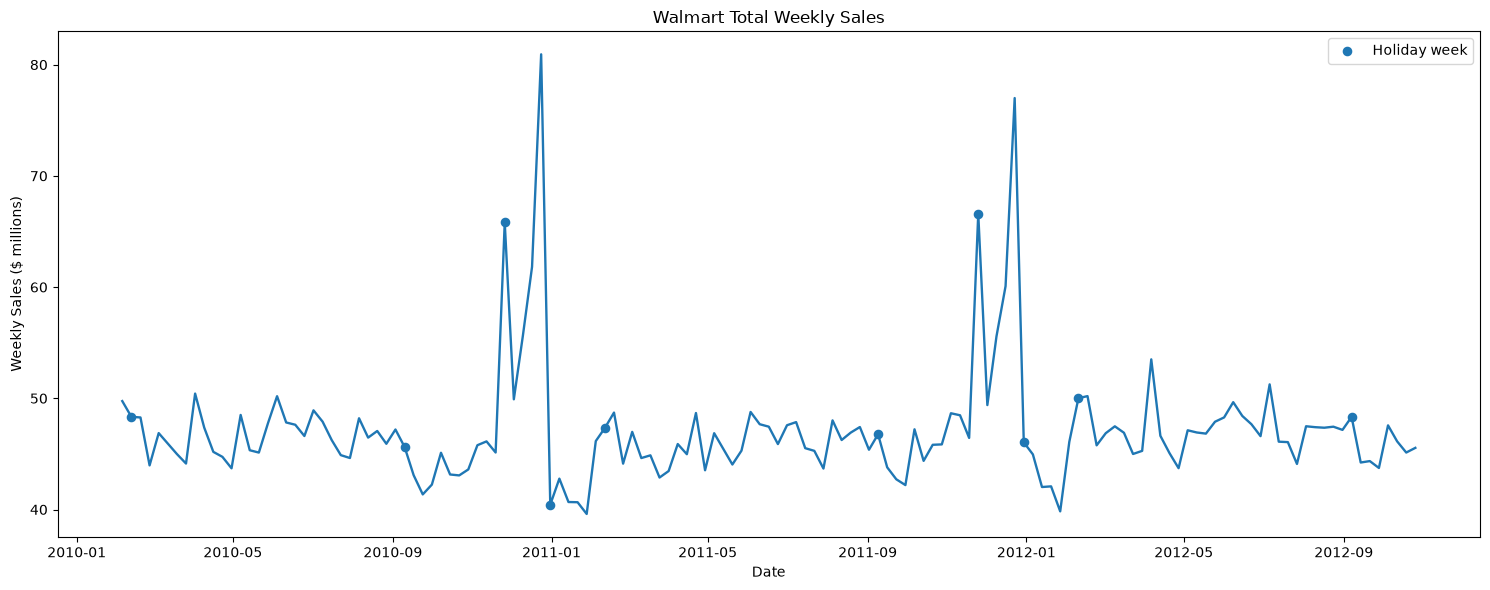

In [10]:
# ============================================================
# 9. PLOT COMPLETE WALMART WEEKLY SALES HISTORY
# ============================================================

plt.figure(figsize=(15, 6))
plt.plot(weekly.index, weekly["Weekly_Sales"] / 1e6, linewidth=1.7)

holiday_dates = weekly.index[weekly["Holiday_Flag"] == 1]
holiday_sales = weekly.loc[holiday_dates, "Weekly_Sales"] / 1e6

plt.scatter(holiday_dates, holiday_sales, s=35, label="Holiday week")

plt.title("Walmart Total Weekly Sales")
plt.xlabel("Date")
plt.ylabel("Weekly Sales ($ millions)")
plt.legend()
plt.tight_layout()
plt.show()

# 10. Rolling average

Weekly retail sales can be noisy.

A moving average smooths short-term variation and makes the underlying direction easier to see.

Here we calculate a **13-week rolling mean**, roughly equivalent to a 3-month moving average.

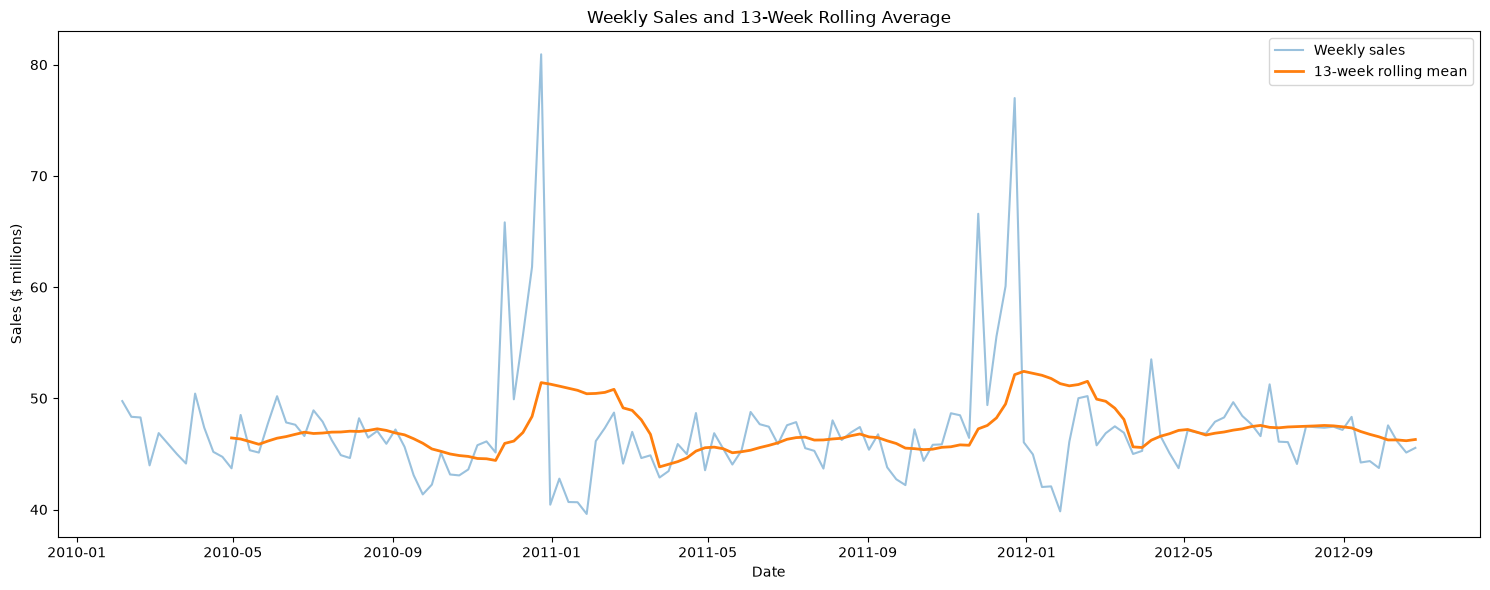

In [11]:
# ============================================================
# 10. 13-WEEK ROLLING MEAN
# ============================================================

rolling_13 = weekly["Weekly_Sales"].rolling(13).mean()

plt.figure(figsize=(15, 6))
plt.plot(weekly.index, weekly["Weekly_Sales"] / 1e6,
         alpha=0.45, label="Weekly sales")
plt.plot(rolling_13.index, rolling_13 / 1e6,
         linewidth=2, label="13-week rolling mean")

plt.title("Weekly Sales and 13-Week Rolling Average")
plt.xlabel("Date")
plt.ylabel("Sales ($ millions)")
plt.legend()
plt.tight_layout()
plt.show()

# 11. STL decomposition

**STL = Seasonal-Trend decomposition using LOESS**

STL separates a time series into:

1. **Trend** — slow long-term movement
2. **Seasonal** — repeated annual pattern
3. **Residual** — remaining unexplained noise

For weekly retail data we use an annual seasonal period of approximately **52 weeks**.

This decomposition helps us understand *why* forecasting models need seasonal components.

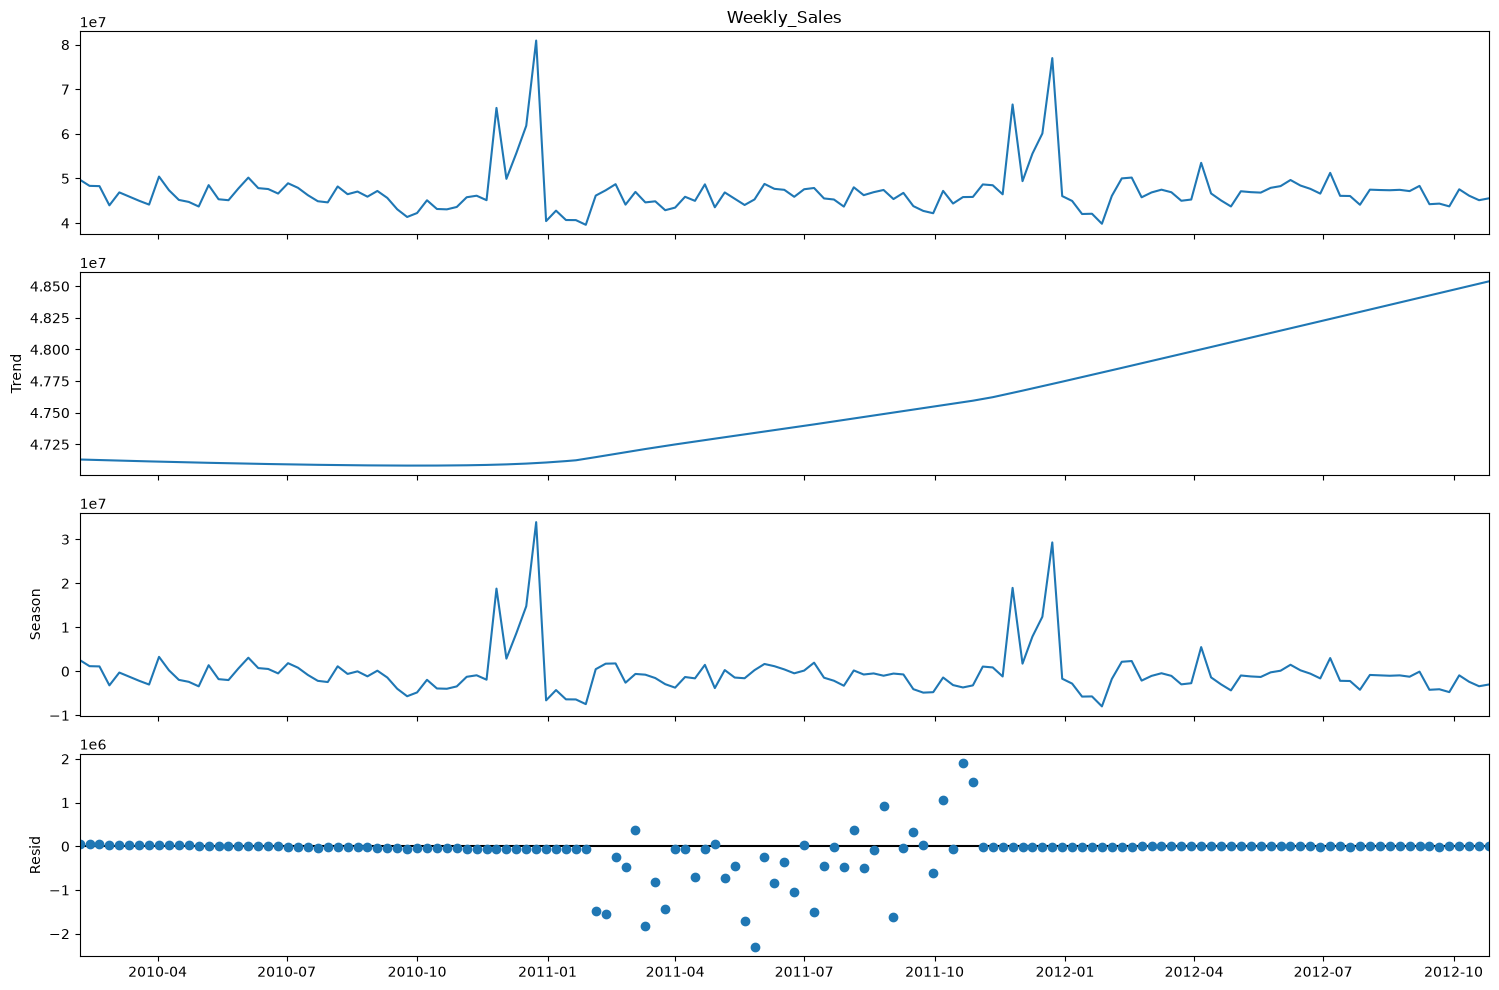

In [12]:
# ============================================================
# 11. STL DECOMPOSITION FOR EXPLORATION
# ============================================================

stl = STL(
    weekly["Weekly_Sales"],
    period=SEASONAL_PERIOD,
    robust=True
)

stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(15, 10)
plt.tight_layout()
plt.show()

# 12. Stationarity check — ADF test

Many classical forecasting methods work better when the statistical behavior of a series is reasonably stable.

The **Augmented Dickey-Fuller (ADF)** test checks for a unit root.

Simplified interpretation:

- **p-value < 0.05:** evidence that the series is stationary
- **p-value ≥ 0.05:** the series may be non-stationary

SARIMAX can handle non-stationarity using differencing, and cross-validation below compares SARIMAX with `d=0` and `d=1`.

In [13]:
# ============================================================
# 12. AUGMENTED DICKEY-FULLER TEST
# ============================================================

adf_result = adfuller(weekly["Weekly_Sales"].dropna())

print("ADF statistic:", round(adf_result[0], 4))
print("p-value:", round(adf_result[1], 6))

if adf_result[1] < 0.05:
    print("Interpretation: Reject H0 -> evidence of stationarity.")
else:
    print("Interpretation: Fail to reject H0 -> series may be non-stationary.")

ADF statistic: -5.9083
p-value: 0.0
Interpretation: Reject H0 -> evidence of stationarity.


# 13. Train-test split: last 3 months

The final **13 weeks** are held out.

The models only learn from the observations before that point.

Then every model predicts exactly the same 13 unseen weeks.

This gives us a fair **out-of-sample forecasting comparison**.

In [14]:
# ============================================================
# 13. CHRONOLOGICAL 3-MONTH HOLDOUT
# ============================================================

target = weekly["Weekly_Sales"].astype(float)
holiday = weekly[["Holiday_Flag"]].astype(float)

train_y = target.iloc[:-TEST_WEEKS]
test_y = target.iloc[-TEST_WEEKS:]

train_x = holiday.iloc[:-TEST_WEEKS]
test_x = holiday.iloc[-TEST_WEEKS:]

print("Training period:")
print(train_y.index.min().date(), "to", train_y.index.max().date())
print("Training observations:", len(train_y))

print("\n3-month test period:")
print(test_y.index.min().date(), "to", test_y.index.max().date())
print("Test observations:", len(test_y))

split_date = test_y.index[0]

Training period:
2010-02-05 to 2012-07-27
Training observations: 130

3-month test period:
2012-08-03 to 2012-10-26
Test observations: 13


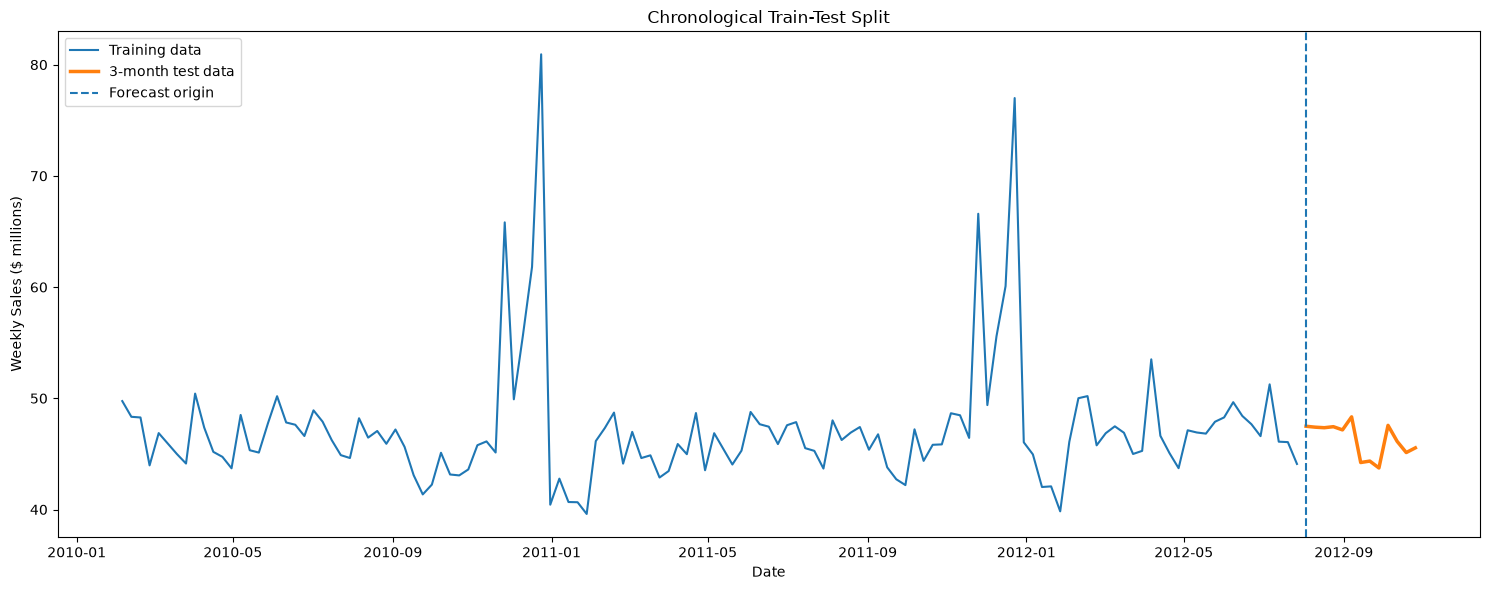

In [15]:
# ============================================================
# 14. VISUALIZE THE TRAIN / TEST SPLIT
# ============================================================

plt.figure(figsize=(15, 6))
plt.plot(train_y.index, train_y / 1e6, label="Training data")
plt.plot(test_y.index, test_y / 1e6, label="3-month test data", linewidth=2.5)
plt.axvline(split_date, linestyle="--", label="Forecast origin")

plt.title("Chronological Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Weekly Sales ($ millions)")
plt.legend()
plt.tight_layout()
plt.show()

# 15. Evaluation metrics

We use several metrics because one number cannot describe forecasting quality perfectly.

### MAE — Mean Absolute Error
Average absolute difference between actual and forecast sales.

### RMSE — Root Mean Squared Error
Similar to MAE, but large errors receive a stronger penalty.

### MAPE — Mean Absolute Percentage Error
Average error expressed as a percentage of actual sales.

### sMAPE — Symmetric MAPE
A more symmetric percentage error metric.

**Lower is better for all four metrics.**

In [16]:
# ============================================================
# 15. METRIC FUNCTION
# ============================================================

def forecast_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    nonzero = actual != 0
    mape = np.mean(
        np.abs((actual[nonzero] - predicted[nonzero]) / actual[nonzero])
    ) * 100

    denominator = np.abs(actual) + np.abs(predicted)
    valid = denominator != 0
    smape = np.mean(
        2 * np.abs(predicted[valid] - actual[valid]) / denominator[valid]
    ) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "sMAPE": smape
    }

predictions = {}
metrics = {}

## 15a. Hyperparameter tuning with time-series cross-validation

`forecast_tuning.py` runs a compact grid search for each of the five algorithms.
Only `train_y` and its known calendar features enter tuning. The final 13 weeks
remain excluded until the selected models are refitted and evaluated.

We use **two expanding folds**, each forecasting **13 weeks**. With 130 training
weeks this gives training windows of **104 and 117 weeks**, preserving at least
two 52-week seasonal cycles. Random shuffling would break time order.

Candidates are ranked by **mean validation RMSE in dollars**. Every fold must
succeed; convergence failures are recorded and excluded. Sales are fitted in
millions of dollars for numerical stability and forecasts are returned in dollars.
Edit `SEARCH_GRIDS` below to extend the search. This is a small search, not a
claim of globally optimal parameters.

The ensemble keeps fixed 20% weights and has no tuned parameters. CV scores are
used for model selection; the separate final holdout provides the evaluation.


In [17]:
# TIME-SERIES CROSS-VALIDATION AND HYPERPARAMETER SEARCH
import json
import sys
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))
from forecast_tuning import default_grids, expanding_folds, forecast_model, tune_models

CV_SPLITS = 2
CV_HORIZON = TEST_WEEKS
SEARCH_GRIDS = default_grids()
tuning = tune_models(
    train_y, train_x, grids=SEARCH_GRIDS,
    n_splits=CV_SPLITS, horizon=CV_HORIZON,
    seasonal_period=SEASONAL_PERIOD, seed=RANDOM_SEED,
)
display(tuning.folds)
best_cv = tuning.leaderboard.query("status == 'ok'").sort_values("mean_cv_rmse").groupby("model", sort=False).head(1)
display(best_cv[["model", "params", "mean_cv_rmse", "std_cv_rmse"]])
failed_folds = tuning.fold_scores.query("status == 'failed'")
print("Failed candidate folds:", len(failed_folds))
if not failed_folds.empty:
    display(failed_folds[["model", "candidate", "fold", "error"]])


Tuning SARIMAX: 4 candidates x 2 folds


  Selected {'order': (1, 1, 1), 'seasonal_ar': 1}; mean CV RMSE $1,766,333


Tuning STL: 4 candidates x 2 folds


  Selected {'robust': False, 'trend': 'add'}; mean CV RMSE $2,042,025


Tuning Prophet: 4 candidates x 2 folds


...

Tuning Theta: 6 candidates x 2 folds


  Selected {'deseasonalize': True, 'theta': 3.0}; mean CV RMSE $1,833,360


,fold,train_start,train_end,train_weeks,validation_start,validation_end,validation_weeks
0,1,2010-02-05,2012-01-27,104,2012-02-03,2012-04-27,13
1,2,2010-02-05,2012-04-27,117,2012-05-04,2012-07-27,13


,model,params,mean_cv_rmse,std_cv_rmse
1,SARIMAX,"{""order"": [1, 1, 1], ""seasonal_ar"": 1}",1.766333e+06,562632.528789
18,Theta,"{""deseasonalize"": true, ""theta"": 3.0}",1.833360e+06,574771.077776
6,STL,"{""robust"": false, ""trend"": ""add""}",2.042025e+06,803123.922309
10,Prophet,"{""changepoint_prior_scale"": 0.1, ""seasonality_...",2.086460e+06,380004.834933
14,UCM,"{""harmonics"": 6, ""level"": ""local level""}",2.536846e+06,420156.548796


Failed candidate folds: 0


# 16. Model 1 — SARIMAX

**SARIMAX** stands for:

> Seasonal AutoRegressive Integrated Moving Average with eXogenous variables

Our model uses:

- AR component → learns dependence on previous sales
- Differencing (`d=0` or `d=1`, selected by CV) → helps with non-stationarity
- MA component → learns from previous forecast errors
- Optional annual seasonal AR behavior (selected by CV) → period of 52 weeks
- `Holiday_Flag` → known external calendar feature

We deliberately keep the parameterization modest because the dataset contains only about 2.75 years of weekly history.

In [18]:
# FIT TUNED SARIMAX ON ALL TRAINING WEEKS
print("Refitting SARIMAX with:", tuning.best_params["SARIMAX"])
sarimax_pred = forecast_model(
    "SARIMAX", train_y, train_x, test_x,
    tuning.best_params["SARIMAX"], seasonal_period=SEASONAL_PERIOD, seed=RANDOM_SEED,
)
predictions["SARIMAX"] = sarimax_pred
metrics["SARIMAX"] = forecast_metrics(test_y, sarimax_pred)
print(metrics["SARIMAX"])


Refitting SARIMAX with: {'order': (1, 1, 1), 'seasonal_ar': 1}


{'MAE': 768744.5750699312, 'RMSE': np.float64(937891.9310821127), 'MAPE': np.float64(1.6590369475877382), 'sMAPE': np.float64(1.640328034412037)}


# 17. Model 2 — STL Forecast

STL itself is fundamentally a **decomposition method** rather than a standalone forecasting equation.

`STLForecast` works like this:

1. Use STL to estimate and remove seasonality.
2. Forecast the seasonally adjusted series.
3. Add the seasonal component back to the forecast.

For the non-seasonal component we tune **Exponential Smoothing with a damped additive trend or no trend**, along with robust STL decomposition.

This gives us an interpretable combination:

> **STL decomposition + Exponential Smoothing**

In [19]:
# FIT TUNED STL ON ALL TRAINING WEEKS
print("Refitting STL with:", tuning.best_params["STL"])
stl_pred = forecast_model(
    "STL", train_y, train_x, test_x,
    tuning.best_params["STL"], seasonal_period=SEASONAL_PERIOD, seed=RANDOM_SEED,
)
predictions["STL"] = stl_pred
metrics["STL"] = forecast_metrics(test_y, stl_pred)
print(metrics["STL"])


Refitting STL with: {'robust': False, 'trend': 'add'}
{'MAE': 920089.8109700272, 'RMSE': np.float64(1181220.5604875982), 'MAPE': np.float64(1.9851549643045845), 'sMAPE': np.float64(1.9538600199730898)}


# 18. Model 3 — Prophet

**Prophet** is an additive forecasting model originally developed at Facebook/Meta.

Conceptually, Prophet models:

> **Trend + Seasonality + Holiday/Regressor effects**

For this weekly dataset:

- yearly seasonality = enabled
- weekly seasonality = disabled because each observation is already one week apart
- daily seasonality = disabled
- `Holiday_Flag` is included as an additional regressor

Prophet is popular because it is relatively easy to use and handles changing trends well.

In [20]:
# FIT TUNED PROPHET ON ALL TRAINING WEEKS
print("Refitting Prophet with:", tuning.best_params["Prophet"])
prophet_pred = forecast_model(
    "Prophet", train_y, train_x, test_x,
    tuning.best_params["Prophet"], seasonal_period=SEASONAL_PERIOD, seed=RANDOM_SEED,
)
predictions["Prophet"] = prophet_pred
metrics["Prophet"] = forecast_metrics(test_y, prophet_pred)
print(metrics["Prophet"])


03:02:11 - cmdstanpy - INFO - Chain [1] start processing


Refitting Prophet with: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 1.0}


03:02:11 - cmdstanpy - INFO - Chain [1] done processing


{'MAE': 760410.25229431, 'RMSE': np.float64(904259.9032140858), 'MAPE': np.float64(1.6282127267537163), 'sMAPE': np.float64(1.6376993285034855)}

# 19. Model 4 — Unobserved Components Model (UCM)

A **Structural Time Series / Unobserved Components Model** represents the observed series as a combination of hidden components.

Here we model:

- **Local level or local linear trend, selected by cross-validation**
- **Annual seasonal pattern**
- **Holiday effect**
- Random irregular noise

Instead of creating 52 separate seasonal states, we use a small number of Fourier-style seasonal harmonics. This makes the model more stable for a dataset with only a few years of history.

In [21]:
# FIT TUNED UCM ON ALL TRAINING WEEKS
print("Refitting UCM with:", tuning.best_params["UCM"])
ucm_pred = forecast_model(
    "UCM", train_y, train_x, test_x,
    tuning.best_params["UCM"], seasonal_period=SEASONAL_PERIOD, seed=RANDOM_SEED,
)
predictions["UCM"] = ucm_pred
metrics["UCM"] = forecast_metrics(test_y, ucm_pred)
print(metrics["UCM"])


Refitting UCM with: {'harmonics': 6, 'level': 'local level'}
{'MAE': 1199725.52749474, 'RMSE': np.float64(1518290.6697121349), 'MAPE': np.float64(2.5706585629752903), 'sMAPE': np.float64(2.6233385428598823)}


# 20. Model 5 — Theta

The **Theta method** transforms a time series into different "theta lines" that emphasize long-term trend and short-term curvature differently.

A classic result in forecasting research is that the Theta method can perform very well on many business time series despite being relatively simple.

The Statsmodels implementation can automatically remove and restore seasonality.

We specify a 52-week seasonal period because the data is weekly.

Cross-validation selects theta (1, 2, or 3) and whether to deseasonalize. The automatic seasonality test is disabled so this setting is controlled by the search.

In [22]:
# FIT TUNED THETA ON ALL TRAINING WEEKS
print("Refitting Theta with:", tuning.best_params["Theta"])
theta_pred = forecast_model(
    "Theta", train_y, train_x, test_x,
    tuning.best_params["Theta"], seasonal_period=SEASONAL_PERIOD, seed=RANDOM_SEED,
)
predictions["Theta"] = theta_pred
metrics["Theta"] = forecast_metrics(test_y, theta_pred)
print(metrics["Theta"])


Refitting Theta with: {'deseasonalize': True, 'theta': 3.0}
{'MAE': 634690.3147072443, 'RMSE': np.float64(848958.1489653748), 'MAPE': np.float64(1.3698702714752977), 'sMAPE': np.float64(1.3750089365053397)}


# 21. Ensemble forecast

Different forecasting algorithms make different assumptions.

For example:

- SARIMAX focuses on autocorrelation and differencing.
- STL explicitly decomposes seasonality.
- Prophet models additive trend/seasonality.
- UCM models hidden structural components.
- Theta combines different transformed views of the series.

An **ensemble** reduces dependence on any single model.

For this project we use a simple and leakage-safe:

> **Equal-weight average ensemble**

Each of the five forecasts gets weight **20%**.

We do **not** choose weights using the test set because that would leak information from the future into model design.

In [23]:
# ============================================================
# 21. EQUAL-WEIGHT ENSEMBLE
# ============================================================

prediction_df = pd.DataFrame(predictions, index=test_y.index)

if prediction_df.shape != (TEST_WEEKS, 5):
    raise ValueError("Expected five model forecasts for every holdout week.")
if not np.isfinite(prediction_df.to_numpy()).all():
    raise ValueError("A model produced missing or non-finite forecasts.")

ensemble_pred = prediction_df.mean(axis=1)

predictions["Ensemble"] = ensemble_pred
metrics["Ensemble"] = forecast_metrics(test_y, ensemble_pred)

print("Ensemble complete.")
print(metrics["Ensemble"])

display(prediction_df.head())

Ensemble complete.
{'MAE': 492268.1233610717, 'RMSE': np.float64(560019.2718502332), 'MAPE': np.float64(1.0583123639385152), 'sMAPE': np.float64(1.059528721934982)}


,SARIMAX,STL,Prophet,UCM,Theta
Date,,,,,
2012-08-03,4.863258e+07,4.956258e+07,4.643702e+07,4.711327e+07,4.917089e+07
2012-08-10,4.729665e+07,4.779433e+07,4.686856e+07,4.766795e+07,4.739390e+07
2012-08-17,4.787278e+07,4.845385e+07,4.778825e+07,4.737999e+07,4.802785e+07
2012-08-24,4.829191e+07,4.894479e+07,4.856804e+07,4.626893e+07,4.768028e+07
2012-08-31,4.659244e+07,4.689548e+07,4.811176e+07,4.477398e+07,4.729413e+07


# 21A. Equal-weight subset ensemble search

This checks every equal-weight combination containing two or more of the five tuned models (26 combinations in total). Lower RMSE is better.

> **Important:** this is an exploratory ranking on the final holdout test set. Do not use it to choose a production ensemble, because choosing based on test performance leaks test information. Use the training-only cross-validation folds to make the final selection.

In [ ]:
# ============================================================
# 21A. EQUAL-WEIGHT COMBINATIONS OF TUNED MODELS
# ============================================================

from itertools import combinations

BASE_MODELS = ["SARIMAX", "STL", "Prophet", "UCM", "Theta"]
combination_rows = []
combination_predictions = {}

# Evaluate all C(5, 2) + C(5, 3) + C(5, 4) + C(5, 5) = 26 equal-weight ensembles.
for size in range(2, len(BASE_MODELS) + 1):
    for members in combinations(BASE_MODELS, size):
        label = " + ".join(members)
        equal_weight_prediction = prediction_df[list(members)].mean(axis=1)
        combination_predictions[label] = equal_weight_prediction
        scores = forecast_metrics(test_y, equal_weight_prediction)
        combination_rows.append({
            "Models": label,
            "Number of models": size,
            "Equal weight per model": 1 / size,
            **scores,
        })

combination_results = (
    pd.DataFrame(combination_rows)
      .sort_values(["RMSE", "MAE"], ignore_index=True)
)

best_equal_weight_combination = combination_results.iloc[0]
best_equal_weight_prediction = combination_predictions[best_equal_weight_combination["Models"]]

display(
    combination_results.assign(
        **{
            "Equal weight per model": lambda frame: frame["Equal weight per model"].map("{:.0%}".format),
            "MAE ($M)": lambda frame: frame["MAE"] / 1e6,
            "RMSE ($M)": lambda frame: frame["RMSE"] / 1e6,
        }
    )[["Models", "Number of models", "Equal weight per model", "MAE ($M)", "RMSE ($M)", "MAPE", "sMAPE"]].head(10).round({"MAE ($M)": 3, "RMSE ($M)": 3, "MAPE": 3, "sMAPE": 3})
)

print("Best equal-weight combination on this holdout:", best_equal_weight_combination["Models"])
print("Models in combination:", int(best_equal_weight_combination["Number of models"]))
print("Weight per model:", f"{best_equal_weight_combination['Equal weight per model']:.0%}")
print("Holdout RMSE:", f"${best_equal_weight_combination['RMSE']:,.0f}")
print("\nExploratory result only: select a production combination using training-only CV, then report this holdout score once.")

# 21B. History-matched equal-weight ensemble forecast

This separate analysis chooses an equal-weight combination whose **two-year forecast shape** is most similar to the observed history. The score compares level, variability, upper and lower sales ranges, annual peaks, annual troughs, and linear trend.

This is a planning and presentation heuristic—not an accuracy metric. Use the holdout RMSE and training-only cross-validation when selecting a model for predictive accuracy.

In [ ]:
# ============================================================
# 21B. FORECAST SHAPE MOST SIMILAR TO HISTORICAL SALES
# ============================================================

from itertools import combinations

FORECAST_WEEKS = 104
BASE_MODELS = ["SARIMAX", "STL", "Prophet", "UCM", "Theta"]

def future_holiday_flags(dates):
    # Repeats the four annual holiday-week patterns used in the source data.
    flags = pd.Series(0.0, index=dates, name="Holiday_Flag")
    for year in sorted(set(dates.year)):
        february = pd.date_range(f"{year}-02-01", f"{year}-02-28", freq="W-FRI")[1]
        labor_day = pd.Timestamp(f"{year}-09-01") + pd.offsets.Week(weekday=0)
        labor_friday = labor_day + pd.offsets.Week(weekday=4)
        black_friday = pd.Timestamp(f"{year}-11-01") + pd.offsets.Week(weekday=4)
        december_fridays = pd.date_range(f"{year}-12-01", f"{year}-12-31", freq="W-FRI")
        for holiday in (february, labor_friday, black_friday, december_fridays[-1]):
            if holiday in flags.index:
                flags.loc[holiday] = 1.0
    return flags

# Refit each tuned model on all observed weeks before creating the planning forecast.
all_y = weekly["Weekly_Sales"]
all_x = weekly[["Holiday_Flag"]]
future_dates = pd.date_range(all_y.index[-1] + pd.Timedelta(days=7), periods=FORECAST_WEEKS, freq="W-FRI")
future_x = pd.DataFrame({"Holiday_Flag": future_holiday_flags(future_dates)}, index=future_dates)
future_model_forecasts = pd.DataFrame(index=future_dates)

for model_name in BASE_MODELS:
    future_model_forecasts[model_name] = forecast_model(
        model_name, all_y, all_x, future_x,
        tuning.best_params[model_name],
        seasonal_period=SEASONAL_PERIOD, seed=RANDOM_SEED,
    )

# Compare each 104-week forecast with the historical level, spread, range,
# two annual peak/trough cycles, and normalized linear trend.
history_values = all_y.to_numpy()
history_mean = history_values.mean()
history_std = history_values.std()
history_q95 = np.quantile(history_values, 0.95)
history_q05 = np.quantile(history_values, 0.05)
history_slope = np.polyfit(np.arange(len(history_values)), history_values, 1)[0] / history_mean
history_cycles = history_values[:104].reshape(2, 52)
history_peak = history_cycles.max(axis=1).mean()
history_trough = history_cycles.min(axis=1).mean()

shape_rows = []
shape_predictions = {}
for size in range(2, len(BASE_MODELS) + 1):
    for members in combinations(BASE_MODELS, size):
        label = " + ".join(members)
        values = future_model_forecasts[list(members)].mean(axis=1).to_numpy()
        future_cycles = values.reshape(2, 52)
        future_slope = np.polyfit(np.arange(len(values)), values, 1)[0] / history_mean
        score = (
            abs(values.mean() - history_mean) / history_mean
            + abs(values.std() - history_std) / history_std
            + abs(np.quantile(values, 0.95) - history_q95) / history_q95
            + abs(np.quantile(values, 0.05) - history_q05) / history_q05
            + abs(future_cycles.max(axis=1).mean() - history_peak) / history_peak
            + abs(future_cycles.min(axis=1).mean() - history_trough) / history_trough
            + 52 * abs(future_slope - history_slope)
        )
        shape_predictions[label] = values
        shape_rows.append({
            "Combination": label,
            "Models": size,
            "Similarity score (lower is better)": score,
            "Forecast mean ($M)": values.mean() / 1e6,
            "Forecast peak ($M)": values.max() / 1e6,
            "Forecast trough ($M)": values.min() / 1e6,
        })

history_similarity_results = pd.DataFrame(shape_rows).sort_values(
    "Similarity score (lower is better)", ignore_index=True
)
best_history_matched = history_similarity_results.iloc[0]
best_history_members = best_history_matched["Combination"].split(" + ")
best_history_prediction = pd.Series(
    shape_predictions[best_history_matched["Combination"]], index=future_dates
)
best_history_test_prediction = prediction_df[best_history_members].mean(axis=1)
weight = 1 / len(best_history_members)

print("Historical shape-matched equal-weight ensemble:", best_history_matched["Combination"])
print("Weight per model:", f"{weight:.0%}")
display(history_similarity_results.head(10).round(3))

# Full history + held-out test prediction + selected two-year forecast.
fig, ax = plt.subplots(figsize=(19, 8.5))
ax.plot(all_y.index, all_y / 1e6, color="#075d82", linewidth=2.4, label="Actual sales (train + test)")
ax.plot(test_y.index, best_history_test_prediction / 1e6, color="#2f9e44", linewidth=2, linestyle=":",
        label=f"{best_history_matched['Combination']} test forecast ({weight:.0%} each)")
ax.plot(future_dates, best_history_prediction / 1e6, color="#2f9e44", linewidth=2.8, linestyle="--",
        label=f"{best_history_matched['Combination']} 2-year forecast ({weight:.0%} each)")
ax.axvline(test_y.index[0], color="#6b7280", linewidth=1.2, linestyle=":", label="Test begins")
ax.axvline(all_y.index[-1], color="#4b5563", linewidth=1.4, linestyle="--", label="2-year forecast begins")
ax.axvspan(test_y.index[0], test_y.index[-1], color="#e5e7eb", alpha=0.4, zorder=0)
ax.set_title(f"Walmart: History-Matched Equal-Weight Ensemble — {best_history_matched['Combination']} ({weight:.0%} each)",
             fontsize=16, weight="bold", pad=36)
ax.set_xlabel("Week")
ax.set_ylabel("Total weekly sales ($ millions)")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.grid(axis="y", alpha=0.28)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.09), ncol=3, frameon=False)
fig.text(0.5, 0.01, "Grey band = held-out test period. Dotted line = test forecast. Dashed line = two-year forecast.",
         ha="center", color="#4b5563", fontsize=9)
fig.tight_layout()
fig.savefig(PROJECT_DIR / "walmart_history_matched_equal_weight_ensemble_2_year_forecast.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved graph: walmart_history_matched_equal_weight_ensemble_2_year_forecast.png")

# 22. Compare all forecasting models

This table is the main quantitative result of the project.

Remember:

**Lower MAE / RMSE / MAPE / sMAPE = better forecast.**

We rank models by RMSE because it gives a stronger penalty to unusually large forecasting errors.

In [24]:
# ============================================================
# 22. MODEL COMPARISON TABLE
# ============================================================

metrics_df = (
    pd.DataFrame(metrics)
      .T
      .sort_values("RMSE")
)

# Add human-readable values in millions for MAE/RMSE.
metrics_display = metrics_df.copy()
metrics_display["MAE ($M)"] = metrics_display["MAE"] / 1e6
metrics_display["RMSE ($M)"] = metrics_display["RMSE"] / 1e6

metrics_display = metrics_display[
    ["MAE ($M)", "RMSE ($M)", "MAPE", "sMAPE"]
]

print("Tuned model performance on the unseen 3-month holdout:")
display(metrics_display.round(3))

best_model = metrics_df.index[0]

print("Best model by RMSE:", best_model)
print(
    "Best RMSE:",
    f"${metrics_df.loc[best_model, 'RMSE']:,.0f}"
)
print(
    "Best MAPE:",
    f"{metrics_df.loc[best_model, 'MAPE']:.2f}%"
)

Tuned model performance on the unseen 3-month holdout:


,MAE ($M),RMSE ($M),MAPE,sMAPE
Ensemble,0.492,0.560,1.058,1.060
Theta,0.635,0.849,1.370,1.375
Prophet,0.760,0.904,1.628,1.638
SARIMAX,0.769,0.938,1.659,1.640
STL,0.920,1.181,1.985,1.954
UCM,1.200,1.518,2.571,2.623


Best model by RMSE: Ensemble
Best RMSE: $560,019
Best MAPE: 1.06%


In [25]:
# ============================================================
# 23. CREATE ONE TABLE WITH ACTUAL + EVERY FORECAST
# ============================================================

final_forecasts = pd.DataFrame({
    "Actual": test_y
})

for model_name, pred in predictions.items():
    final_forecasts[model_name] = np.asarray(pred)

display(final_forecasts)

,Actual,SARIMAX,STL,Prophet,UCM,Theta,Ensemble
Date,,,,,,,
2012-08-03,47485899.56,4.863258e+07,4.956258e+07,4.643702e+07,4.711327e+07,4.917089e+07,4.818327e+07
2012-08-10,47403451.04,4.729665e+07,4.779433e+07,4.686856e+07,4.766795e+07,4.739390e+07,4.740428e+07
2012-08-17,47354452.05,4.787278e+07,4.845385e+07,4.778825e+07,4.737999e+07,4.802785e+07,4.790454e+07
2012-08-24,47447323.60,4.829191e+07,4.894479e+07,4.856804e+07,4.626893e+07,4.768028e+07,4.795079e+07
2012-08-31,47159639.43,4.659244e+07,4.689548e+07,4.811176e+07,4.477398e+07,4.729413e+07,4.673356e+07
2012-09-07,48330059.31,4.965005e+07,4.827279e+07,4.711058e+07,4.549736e+07,4.719995e+07,4.754615e+07
2012-09-14,44226038.65,4.527391e+07,4.529396e+07,4.392579e+07,4.298278e+07,4.436814e+07,4.436892e+07
2012-09-21,44354547.11,4.437756e+07,4.420824e+07,4.319316e+07,4.325162e+07,4.293033e+07,4.359218e+07
2012-09-28,43734899.40,4.394243e+07,4.367584e+07,4.429119e+07,4.399171e+07,4.314036e+07,4.380830e+07


# 24. FINAL FORECAST GRAPH — ALL MODELS + ENSEMBLE

This is the final visualization you can place in your GitHub README or discuss in an interview.

The chart shows:

- Actual Walmart sales for the unseen 3-month period
- Tuned SARIMAX forecast
- STL forecast
- Prophet forecast
- UCM forecast
- Theta forecast
- Ensemble forecast

All model parameters were selected using training-only cross-validation.

Only the final 13 weeks are shown so the differences between models remain readable.

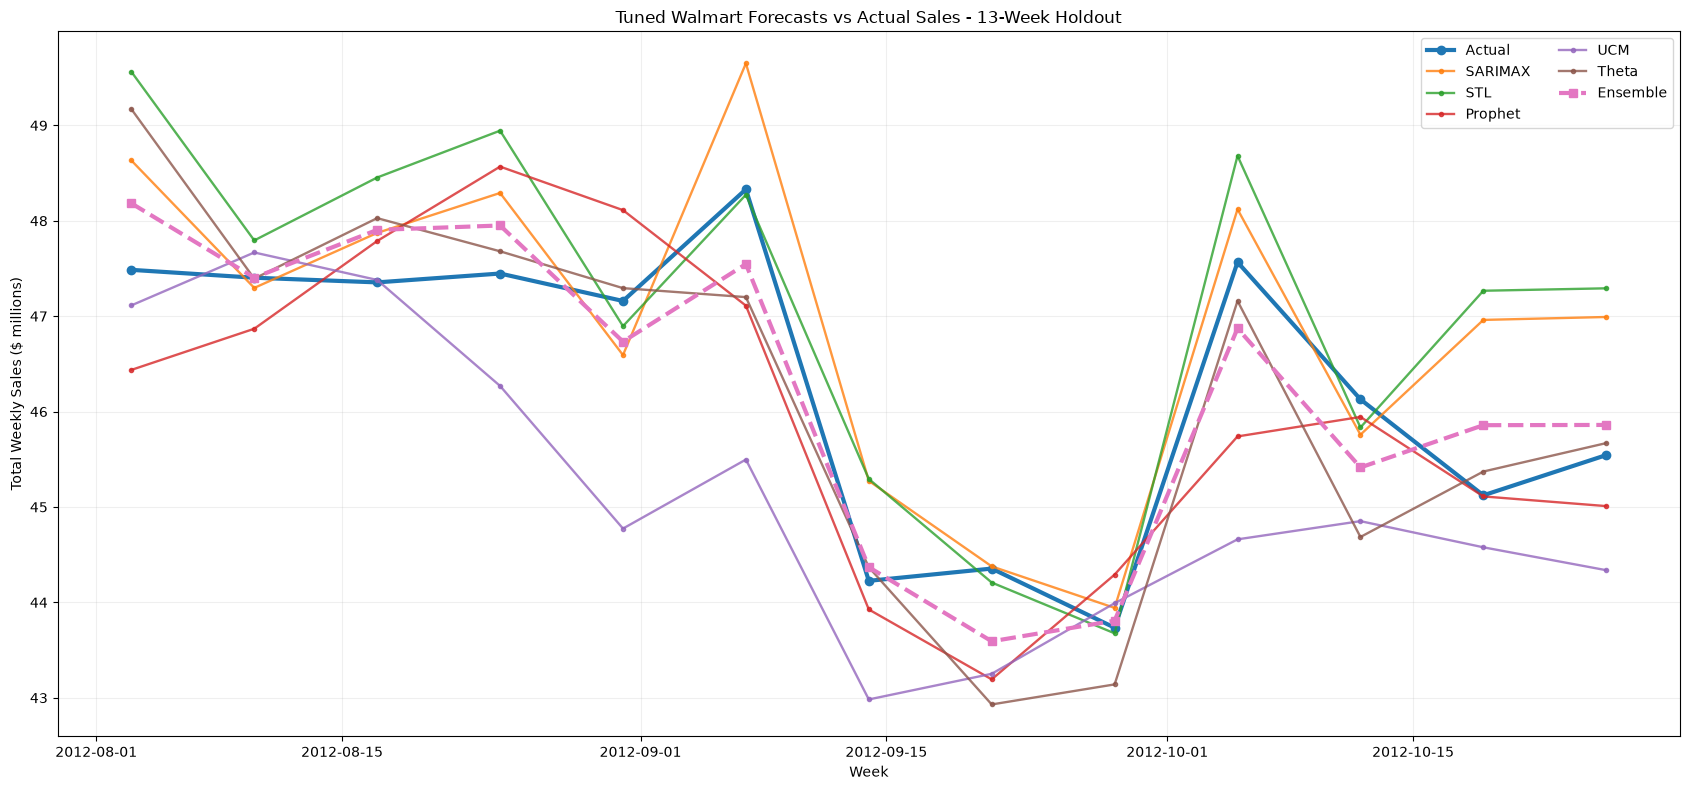

Saved graph: walmart_all_models_3_month_forecast.png


In [26]:
# ============================================================
# 24. FINAL GRAPH: ALL ALGORITHMS AND ENSEMBLE
# ============================================================

plt.figure(figsize=(17, 8))

# Actual values
plt.plot(
    test_y.index,
    test_y.values / 1e6,
    marker="o",
    linewidth=3,
    label="Actual"
)

# Individual model forecasts
for model_name in ["SARIMAX", "STL", "Prophet", "UCM", "Theta"]:
    plt.plot(
        test_y.index,
        final_forecasts[model_name].values / 1e6,
        marker=".",
        linewidth=1.7,
        alpha=0.8,
        label=model_name
    )

# Make ensemble slightly more prominent
plt.plot(
    test_y.index,
    final_forecasts["Ensemble"].values / 1e6,
    marker="s",
    linewidth=3,
    linestyle="--",
    label="Ensemble"
)

plt.title("Tuned Walmart Forecasts vs Actual Sales - 13-Week Holdout")
plt.xlabel("Week")
plt.ylabel("Total Weekly Sales ($ millions)")
plt.legend(ncol=2)
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    PROJECT_DIR / "walmart_all_models_3_month_forecast.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved graph: walmart_all_models_3_month_forecast.png")


# 25. Error comparison chart

The line chart tells us *where* models were right or wrong.

This bar chart gives a quick model ranking based on RMSE.

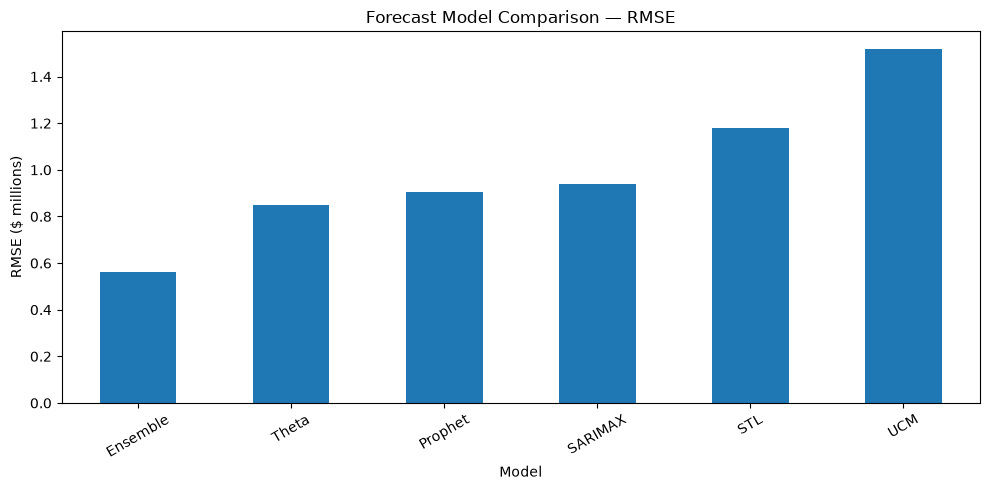

In [27]:
# ============================================================
# 25. RMSE COMPARISON
# ============================================================

rmse_plot = (metrics_df["RMSE"] / 1e6).sort_values()

plt.figure(figsize=(10, 5))
rmse_plot.plot(kind="bar")
plt.title("Forecast Model Comparison — RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE ($ millions)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 26. Save project outputs

The notebook saves:

1. `walmart_model_metrics.csv`
2. `walmart_3_month_forecasts.csv`
3. `walmart_all_models_3_month_forecast.png`

These can be reused in a README, presentation, or Streamlit dashboard.

The tuning audit is also saved: `walmart_best_params.json`, `walmart_cv_results.csv`, `walmart_cv_fold_scores.csv`, `walmart_cv_folds.csv`, and `walmart_cv_predictions.csv`.


In [28]:
# ============================================================
# 26. SAVE RESULTS
# ============================================================

metrics_df.to_csv(PROJECT_DIR / "walmart_model_metrics.csv")
final_forecasts.to_csv(PROJECT_DIR / "walmart_3_month_forecasts.csv")

print("Files saved successfully:")
print("- walmart_model_metrics.csv")
print("- walmart_3_month_forecasts.csv")
print("- walmart_all_models_3_month_forecast.png")
# Save the complete tuning audit alongside the final holdout results.
tuning.leaderboard.to_csv(PROJECT_DIR / "walmart_cv_results.csv", index=False)
tuning.fold_scores.to_csv(PROJECT_DIR / "walmart_cv_fold_scores.csv", index=False)
tuning.folds.to_csv(PROJECT_DIR / "walmart_cv_folds.csv", index=False)
tuning.cv_predictions.to_csv(PROJECT_DIR / "walmart_cv_predictions.csv", index=False)
(PROJECT_DIR / "walmart_best_params.json").write_text(
    json.dumps(tuning.best_params, indent=2) + "\n", encoding="utf-8"
)
print("Saved CV candidates, fold scores, fold dates, validation predictions and best parameters.")


Files saved successfully:
- walmart_model_metrics.csv
- walmart_3_month_forecasts.csv
- walmart_all_models_3_month_forecast.png
Saved CV candidates, fold scores, fold dates, validation predictions and best parameters.


# 27. What each algorithm learned

### SARIMAX
Models autocorrelation, differencing, annual seasonality and known holiday effects.

### STL
Explicitly separates annual seasonality from the underlying trend and then forecasts the adjusted series.

### Prophet
Represents sales as trend + yearly seasonality + holiday-regressor effects.

### UCM
Treats trend and seasonality as hidden structural states that evolve over time.

### Theta
Creates transformed versions of the series that capture different amounts of trend/curvature and combines them.

### Ensemble
Averages forecasts from multiple models to reduce model-specific errors.

---

# 28. Interview explanation — 60-second version

> I built an end-to-end Walmart retail sales forecasting project using weekly sales data from 45 stores. I aggregated store-level sales into a Walmart-wide weekly time series and used the final 13 weeks as a strict three-month out-of-sample holdout to avoid temporal leakage. I analyzed trend and annual seasonality using STL decomposition and then benchmarked five forecasting approaches: SARIMAX with a holiday exogenous variable, STL with exponential smoothing, Prophet, an Unobserved Components Model, and Theta. I compared the models using MAE, RMSE, MAPE and sMAPE and also created an equal-weight ensemble to reduce model-specific variance. Finally, I visualized every model against the actual three-month holdout and saved the forecast and evaluation outputs.

---

# 29. Resume-ready project description

After running the notebook, use the actual result printed above rather than inventing a metric.

### Project title
**Walmart Retail Sales Forecasting | Time Series**

### Resume bullets
- Built an end-to-end weekly retail sales forecasting pipeline using Walmart sales data across 45 stores, applying chronological validation with a 13-week out-of-sample holdout.
- Benchmarked **SARIMAX, STL, Prophet, UCM and Theta** forecasting approaches using MAE, RMSE, MAPE and sMAPE, and developed an equal-weight ensemble for robust multi-model forecasting.
- Analyzed annual seasonality, trend and holiday effects and generated comparative three-month forecasts with model-level performance visualization.

You can replace the second bullet with your actual best metric after executing the notebook, for example:

> Achieved a holdout MAPE of **X.XX%** using the best-performing forecasting approach.

Only write that after the notebook gives you the real value.

# 30. Important forecasting concepts you should know for interviews

## Forecast horizon
How far into the future we predict.  
Here: **13 weeks ≈ 3 months**.

## Seasonality
A pattern that repeats at regular intervals.  
Here: Walmart sales may show approximately annual repetition, so we use **52 weeks**.

## Trend
The longer-term direction of sales.

## Exogenous variable
Information outside the target series that can help prediction.  
Here: `Holiday_Flag`.

## Temporal leakage
Using information from the future while training or selecting a model.

## Backtesting / holdout
Simulating a real forecast by training only on earlier data and evaluating on later unseen observations.

## Point forecast
A single estimated value for each future timestamp.

## Ensemble
Combining predictions from multiple models instead of relying on one forecasting method.

---

## A final note

A model is not considered good simply because it is more complicated.

The correct question is:

> **Which model generalizes best to unseen future observations?**

That is why this project compares every method on the same three-month holdout.